In [2]:
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from fermion import *
from entropy import *

exact_model = Fermion_Model(tunneling=1.0, coulomb=0.5)
analog_model = Analog_Fermion(exact_model)

initial_state = Statevector.from_label('1100110011001100').data  # Example initial state
time=np.linspace(0,5,51)
exact_state=initial_state
analog_state=initial_state
time_step=0.1

ModuleNotFoundError: No module named 'openfermion'

In [ ]:
from math import sqrt
error=[]
fro_norm=[]
d=2**16
H_noise=get_sparse_operator(exact_model.H-analog_model.H).toarray()
for t in tqdm(time):
    exact_state = exact_model.evolve_state(exact_state, time_step,exact_model.H)
    analog_state = analog_model.evolve_state(analog_state, time_step,analog_model.H)
    error.append(np.linalg.norm(exact_state - analog_state))
    fro_norm.append(np.linalg.norm(H_noise,'fro')/np.sqrt(d)*t)

In [ ]:
plt.plot(time,error)
plt.plot(time,fro_norm)
plt.xlabel('Time')
plt.ylabel('Error')
plt.grid()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
error=[]
entropy12=[]
entropy13=[]
entropy14=[]
entropy15=[]
for _ in tqdm(time):
    analog_state = analog_model.evolve_state(exact_state, time_step, analog_model.H)
    exact_state = exact_model.evolve_state(exact_state, time_step, exact_model.H)
    error.append(np.linalg.norm(exact_state - analog_state))
    # entropy.append(RDM_entropy(analog_state, 4,16)[-1])
    rho=partial_trace(Statevector(analog_state),[4,5,6,7,8,9,10,11,12,13,14,15])
    entropy12.append(von_neumann_entropy(rho))
    rho=partial_trace(Statevector(analog_state),[2,3,6,7,8,9,10,11,12,13,14,15])
    entropy13.append(von_neumann_entropy(rho))
    rho=partial_trace(Statevector(analog_state),[2,3,4,5,8,9,10,11,12,13,14,15])
    entropy14.append(von_neumann_entropy(rho))
    rho=partial_trace(Statevector(analog_state),[2,3,4,5,6,7,10,11,12,13,14,15])
    entropy15.append(von_neumann_entropy(rho))

In [ ]:
fro_norm=np.linalg.norm(H_noise,'fro')/sqrt(d)*time_step

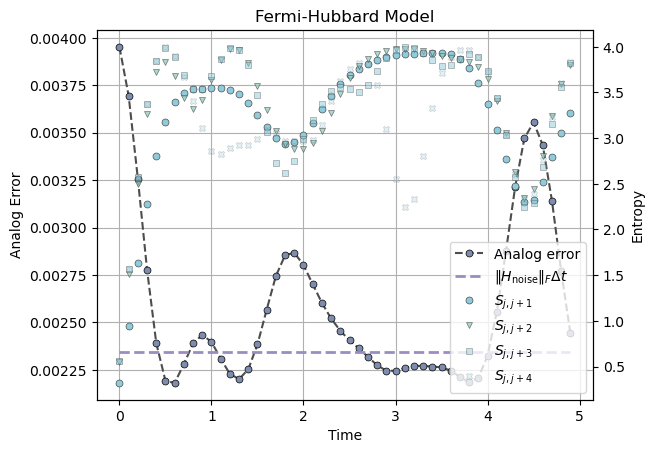

In [24]:
p11=plt.plot(time[:-1], error[:-1],color='0.3', marker='o', markersize=5, mfc="#7E8CAD", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Analog error')
p12=plt.plot(time[:-1], [fro_norm]*len(time[:-1]),'--',color="#998DC2",linewidth=2,label=r'$\|H_{\text{noise}}\|_F\Delta t$')
plt.grid()
plt.xlabel('Time')
plt.ylabel('Analog Error')
# plt.ylim( top=0.3)
ax1=plt.gca()
ax2 = ax1.twinx()
p21=ax2.plot(time[:-1], entropy12[:-1],color='0.3', marker='o', markersize=5, mfc="#8ECBDB", linestyle='', markeredgewidth=0.5,label=r'$S_{j,j+1}$')
p22=ax2.plot(time[:-1], entropy13[:-1],color='0.3', marker='v', markersize=5, mfc="#8ECDBD", linestyle='', markeredgewidth=0.5,label=r'$S_{j,j+2}$',alpha=0.75)
p23=ax2.plot(time[:-1], entropy14[:-1],color='0.3', marker='s', markersize=5, mfc="#8ECBDB", linestyle='', markeredgewidth=0.5,label=r'$S_{j,j+3}$',alpha=0.5)
p24=ax2.plot(time[:-1], entropy15[:-1],color='0.3', marker='X', markersize=5, mfc="#8ECBDB", linestyle='', markeredgewidth=0.5,label=r'$S_{j,j+4}$',alpha=0.25)
ax2.set_ylabel('Entropy')
lns=p11+p12+p21+p22+p23+p24
labs=[l.get_label() for l in lns]
plt.legend(lns, labs, loc=0)

plt.title('Fermi-Hubbard Model')
plt.savefig('Figures/fermion_error_new3.pdf', bbox_inches='tight',dpi=600)
plt.show()
